In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import os

In [2]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [3]:
# Hyperparameters
batch_size = 32
lr = 0.0002
beta1 = 0.5
beta2 = 0.999
z_dim = 100
num_epochs = 100
img_size = 32
channels = 3
num_refinements = 3

In [4]:
# Create directories for outputs
os.makedirs('outputs', exist_ok=True)
os.makedirs('models', exist_ok=True)

# Data preprocessing
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [5]:
print("Loading CIFAR-10 dataset...")
train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

print(f'Dataset size: {len(train_dataset)}')
print(f'Number of batches: {len(train_loader)}')

Loading CIFAR-10 dataset...
Dataset size: 50000
Number of batches: 1563


In [6]:
# Residual Block
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, 1, 1)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, 3, 1, 1)
        self.bn2 = nn.BatchNorm2d(channels)
        self.relu = nn.ReLU(inplace=True)
    
    def forward(self, x):
        residual = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += residual
        out = self.relu(out)
        return out

In [7]:
# R3GAN Generator
class Generator(nn.Module):
    def __init__(self, z_dim, img_channels, num_refinements=3):
        super(Generator, self).__init__()
        self.num_refinements = num_refinements
        
        # Initial generation
        self.init_gen = nn.Sequential(
            nn.ConvTranspose2d(z_dim, 1024, 4, 1, 0),
            nn.BatchNorm2d(1024),
            nn.ReLU(True),
            nn.ConvTranspose2d(1024, 512, 4, 1, 0),
            nn.BatchNorm2d(512),
            nn.ReLU(True),
            nn.ConvTranspose2d(512, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(True)
        )
        
        # Refinement module with residual blocks
        self.refine_blocks = nn.ModuleList([
            nn.Sequential(
                ResidualBlock(256),
                ResidualBlock(256)
            ) for _ in range(num_refinements)
        ])
        
        # LSTM for recurrent refinement
        self.lstm = nn.LSTM(256, 256, batch_first=True)

        # Final output layer
        self.final = nn.Sequential(
            nn.Conv2d(256, img_channels, 3, 1, 1),
            nn.Tanh()
        )
    
    def forward(self, z):
        # Initial generation
        x = self.init_gen(z)
        
        # Recurrent refinement
        b, c, h, w = x.shape
        
        for refine_block in self.refine_blocks:
            # Apply residual refinement
            x_refined = refine_block(x)
            
            # Reshape for LSTM processing
            x_flat = x_refined.view(b, c, -1).permute(0, 2, 1)
            lstm_out, _ = self.lstm(x_flat)
            x = lstm_out.permute(0, 2, 1).view(b, c, h, w)
            
        # Final output
        img = self.final(x)
        return img



In [8]:
# R3GAN Discriminator
class Discriminator(nn.Module):
    def __init__(self, img_channels):
        super(Discriminator, self).__init__()
        
        self.model = nn.Sequential(
            nn.Conv2d(img_channels, 256, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(256, 512, 4, 2, 1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(512, 1, 2, 1, 0),
            nn.Sigmoid()
        )
    
    def forward(self, img):
        validity = self.model(img)
        return validity.view(-1, 1)



In [9]:
# Initialize models
print("\nInitializing models...")
G = Generator(z_dim, channels, num_refinements).to(device)
D = Discriminator(channels).to(device)


Initializing models...


In [10]:
# Initialize weights
def weights_init(m):
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d, nn.BatchNorm2d)):
        nn.init.normal_(m.weight.data, 0.0, 0.02)

G.apply(weights_init)
D.apply(weights_init)

Discriminator(
  (model): Sequential(
    (0): Conv2d(3, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(512, 1, kernel_size=(2, 2), stride=(1, 1))
    (12): Sigmoid()
  )
)

In [11]:
# Optimizers
opt_G = optim.Adam(G.parameters(), lr=lr, betas=(beta1, beta2))
opt_D = optim.Adam(D.parameters(), lr=lr, betas=(beta1, beta2))

# Loss function
criterion = nn.BCELoss()

print(f'Generator parameters: {sum(p.numel() for p in G.parameters()):,}')
print(f'Discriminator parameters: {sum(p.numel() for p in D.parameters()):,}')

Generator parameters: 20,799,619
Discriminator parameters: 3,163,009


In [12]:
# Training Loop
print("\nStarting training...\n")

# Fixed noise for visualization
fixed_noise = torch.randn(256, z_dim, 1, 1).to(device)

# Training history
g_losses = []
d_losses = []

for epoch in range(num_epochs):
    g_loss_epoch = 0
    d_loss_epoch = 0
    
    for i, (real_imgs, _) in enumerate(tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')):
        batch = real_imgs.size(0)
        real_imgs = real_imgs.to(device)
        
        # Labels
        real_labels = torch.ones(batch, 1).to(device)
        fake_labels = torch.zeros(batch, 1).to(device)
        
        # Train Discriminator
        opt_D.zero_grad()
        
        # Real images
        real_out = D(real_imgs)
        d_loss_real = criterion(real_out, real_labels)
        
        # Fake images
        z = torch.randn(batch, z_dim, 1, 1).to(device)
        fake_imgs = G(z)
        fake_out = D(fake_imgs.detach())
        d_loss_fake = criterion(fake_out, fake_labels)
        
        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        opt_D.step()
        
        # Train Generator
        opt_G.zero_grad()
        
        fake_out = D(fake_imgs)
        g_loss = criterion(fake_out, real_labels)
        
        g_loss.backward()
        opt_G.step()
        
        g_loss_epoch += g_loss.item()
        d_loss_epoch += d_loss.item()
    
    # Record losses
    g_losses.append(g_loss_epoch / len(train_loader))
    d_losses.append(d_loss_epoch / len(train_loader))
    
    print(f'Epoch [{epoch+1}/{num_epochs}] | D Loss: {d_losses[-1]:.4f} | G Loss: {g_losses[-1]:.4f}')
    
    # Generate and save images
    if (epoch + 1) % 10 == 0:
        with torch.no_grad():
            fake_imgs = G(fixed_noise).cpu()
            grid = torchvision.utils.make_grid(fake_imgs, nrow=8, normalize=True)
            plt.figure(figsize=(12, 12))
            plt.imshow(grid.permute(1, 2, 0))
            plt.axis('off')
            plt.title(f'Epoch {epoch+1}')
            plt.savefig(f'outputs/epoch_{epoch+1}.png', bbox_inches='tight')
            plt.close()
            print(f'Saved image: outputs/epoch_{epoch+1}.png')


# Plot Training Losses
print("\nGenerating loss plot...")
plt.figure(figsize=(10, 5))
plt.plot(g_losses, label='Generator Loss')
plt.plot(d_losses, label='Discriminator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('R3GAN Training Losses')
plt.legend()
plt.grid(True)
plt.savefig('outputs/training_losses.png')
print('Saved: outputs/training_losses.png')
plt.show()



Starting training...



Epoch 1/100:   0%|          | 0/1563 [00:00<?, ?it/s]


ValueError: Using a target size (torch.Size([32, 1])) that is different to the input size (torch.Size([128, 1])) is deprecated. Please ensure they have the same size.


Generating final images...
Saved: outputs/final_generated_images.png


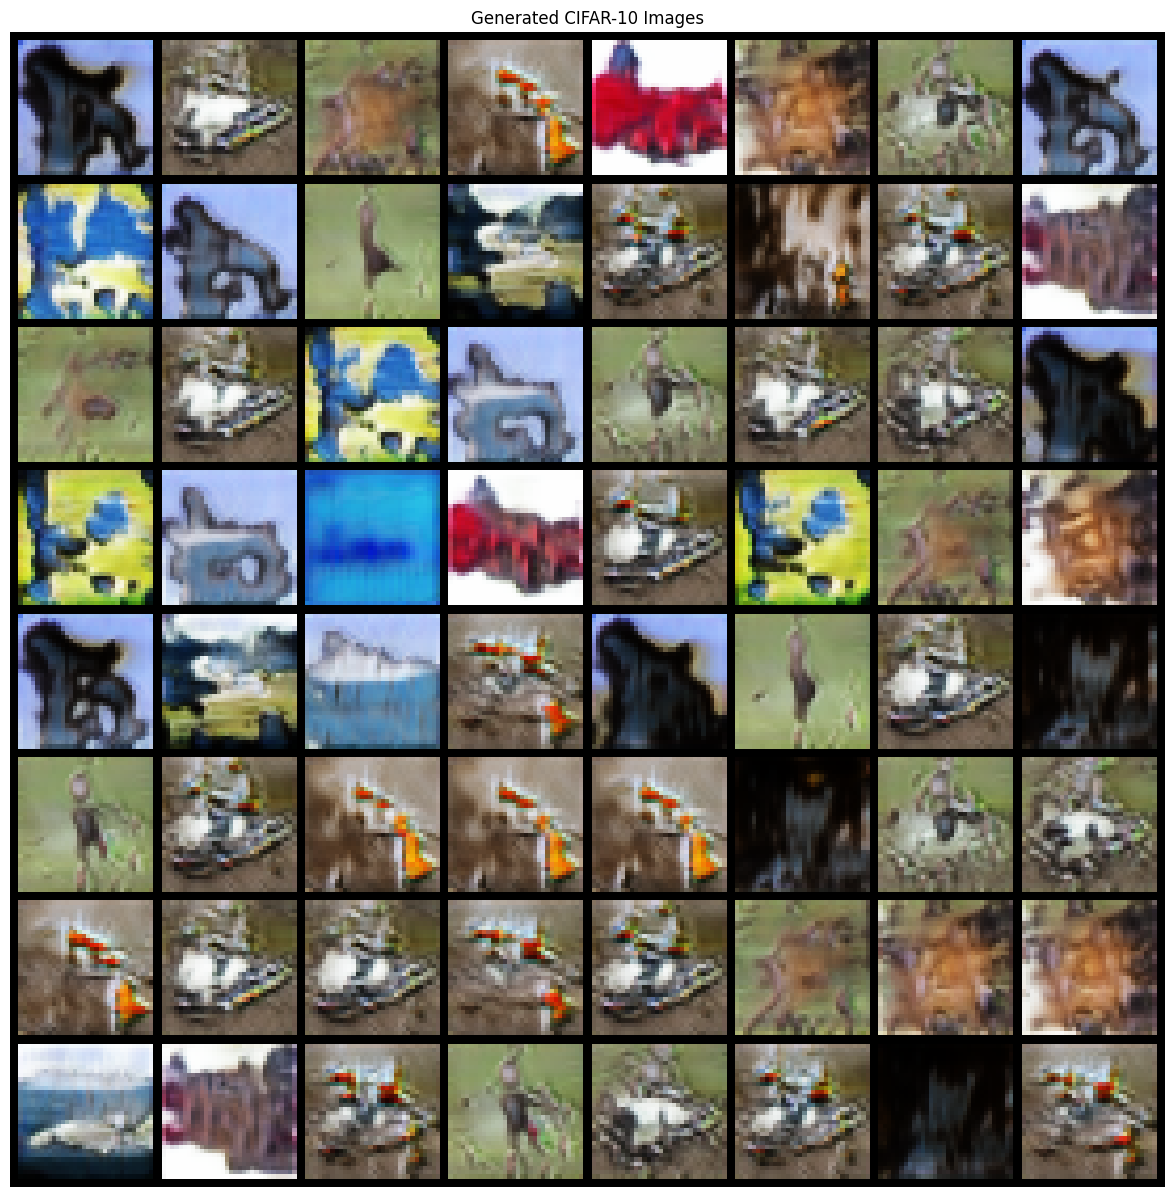

In [ ]:
# Generate Final Images
print("\nGenerating final images...")
G.eval()
with torch.no_grad():
    z = torch.randn(64, z_dim, 1, 1).to(device)
    generated_imgs = G(z).cpu()
    grid = torchvision.utils.make_grid(generated_imgs, nrow=8, normalize=True)
    
    plt.figure(figsize=(15, 15))
    plt.imshow(grid.permute(1, 2, 0))
    plt.axis('off')
    plt.title('Generated CIFAR-10 Images')
    plt.savefig('outputs/final_generated_images.png', bbox_inches='tight')
    print('Saved: outputs/final_generated_images.png')
    plt.show()

In [ ]:
# Save Models
print("\nSaving models...")
torch.save(G.state_dict(), 'models/r3gan_generator.pth')
torch.save(D.state_dict(), 'models/r3gan_discriminator.pth')
print('Models saved successfully!')
print('- models/r3gan_generator.pth')
print('- models/r3gan_discriminator.pth')

print("\n✓ Training complete!")


Saving models...
Models saved successfully!
- models/r3gan_generator.pth
- models/r3gan_discriminator.pth

✓ Training complete!
